In [91]:
import pandas as pd
import nltk
import re
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

## Preprocessing

#### Merge all text columns into one

In [45]:
def merge_cols(row, columns):
    merged = ''
    is_na = row.isna()
    for col in columns:
        if not is_na[col]:
            merged = merged + row[col] + ' '
    merged = merged[:-1]
    return merged

In [96]:
def tokenize(text):
    # Remove single periods, commas, apostrophes, quotes, and parentheses
    text = re.sub(r'(?<!\.)\.(?!\.)|,|\'|\"|\(|\)|‘|’|“|”', '', text)
    
    # Use nltk to split into tokens
    tokens = nltk.word_tokenize(text)
    
    # I'm leaving other punctuation since it can be an indicator of being spam, such as many exclamation marks, etc.
    # nltk tokenize should mostly split those punctuations into their own tokens
    
    # remove stopwords and numbers
    stopwords = set(nltk.corpus.stopwords.words('english'))
    filtered = [w for w in tokens if not ((w.lower() in stopwords) or (w.isnumeric()))]
    return filtered

In [97]:
def split(df):
    """
    Removes *standard* punctuation and stop words
    Concatenates all columns other than index
    Leaves capitalization, as that information could be used as another feature
    (e.g. number of all-caps words)
    :param df:
    :return: original dataframe, preprocessed dataframe
    """
    text_cols = df.columns[1:]
    out_df = pd.DataFrame(df.iloc[:, 0].values, columns=['class'])
    out_df['body'] = df.apply(lambda row: tokenize(merge_cols(row, text_cols)), axis='columns')
    return out_df

In [46]:
def merge_all(df=None, in_file=None, out_file=None):
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file, encoding = 'ISO-8859-1')
    text_cols = df.columns[1:]
    out_df = pd.DataFrame(df.iloc[:, 0].values, columns=['class'])
    out_df['body'] = df.apply(lambda row: merge_cols(row, text_cols), axis='columns')
    if out_file is not None:
        out_df.to_csv(out_file, index=False)
    return out_df

In [47]:
_ = merge_all(in_file='data/spam.csv', out_file='data/mergedSpam.csv')

### Get Frequencies

In [85]:
def vectorize(df=None, in_file=None, out_file=None, vectorizer_func=CountVectorizer):
    """
    Expects a dataframe that has been merged. This should only be called on training set
    Use vectorizer_transform_df after to vectorize testing set. (This doesnt really matter for wordcount but does for tfidf)
    :param df: 
    :param in_file: 
    :param out_file: 
    :param vectorizer_func: 
    :return: 
    """
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file, encoding = 'ISO-8859-1')
    vectorizer = vectorizer_func(tokenizer=tokenize, token_pattern=None, stop_words='english')
    vectors = vectorizer.fit_transform(df['body'])
    out_df = pd.DataFrame.sparse.from_spmatrix(vectors, columns=vectorizer.get_feature_names_out())
    # Since class could be a word, I am using .class.
    df.reset_index(drop=True, inplace=True)
    out_df['.class.'] = df['class']
    if out_file is not None:
        out_df.to_csv(out_file, index=False)
    return out_df, vectorizer

In [86]:
def vectorizer_transform_df(vectorizer, df=None, in_file=None, out_file=None):
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file, encoding = 'ISO-8859-1')
    vectors = vectorizer.transform(df['body'])
    out_df = pd.DataFrame.sparse.from_spmatrix(vectors, columns=vectorizer.get_feature_names_out())
    df.reset_index(drop=True, inplace=True)
    out_df['.class.'] = df['class']
    if out_file is not None:
        out_df.to_csv(out_file, index=False)
    return out_df

# Multinomial NB

In [87]:
def train(df=None, in_file=None, classifier=MultinomialNB, **kwargs):
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file)
    clf = classifier(**kwargs)
    clf.fit(df.drop(columns=['.class.']), df['.class.'])
    return clf

In [88]:
def test(df=None, in_file=None, vectorizer_func=CountVectorizer, frac=0.2, classifier=MultinomialNB, **kwargs):
    """
    Expects a dataframe that has been merged but not vectorized
    :param df: 
    :param in_file: 
    :param vectorizer_fun: 
    :param frac: 
    :param classifier: 
    :param kwargs: 
    :return: 
    """
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file)
    train_df, test_df = train_test_split(df, train_size=frac)
    train_df, vectorizer = vectorize(train_df, vectorizer_func=vectorizer_func)
    #train_df = smote.fit_resample(train_df)
    #display(train_df)
    test_df = vectorizer_transform_df(vectorizer, test_df)
    clf = train(df=train_df, classifier=classifier, **kwargs)
    training_accuracy = clf.score(train_df.drop(columns=['.class.']), train_df['.class.'])
    testing_accuracy = clf.score(test_df.drop(columns=['.class.']), test_df['.class.'])
    print(f'Overall Accuracy')
    print(f'Training Accuracy: {training_accuracy:.2f}')
    print(f'Testing Accuracy: {testing_accuracy:.2f}')
    train_proportions = train_df['.class.'].value_counts(normalize=True)
    test_proportions = test_df['.class.'].value_counts(normalize=True)
    class_labels = ['ham', 'spam']
    for label in class_labels:
        label_train_df = train_df.loc[train_df['.class.'] == label]
        label_test_df = test_df.loc[test_df['.class.'] == label]
        label_train_accuracy = clf.score(label_train_df.drop(columns=['.class.']), label_train_df['.class.'])
        label_test_accuracy = clf.score(label_test_df.drop(columns=['.class.']), label_test_df['.class.'])
        print(f'{label} Stats:')
        print(f'Proportion of Training Set: {train_proportions[label]:.2f}')
        print(f'Training Accuracy: {label_train_accuracy:.2f}')
        print(f'Proportion of Test Set: {test_proportions[label]:.2f}')
        print(f'Testing Accuracy: {label_test_accuracy:.2f}')

In [103]:
def test_cross_validation_nbc(df=None, in_file=None, vectorizer_func=CountVectorizer, 
                              folds=10, **kwargs):
    """
    Perform k-fold cross-validation for a Naive Bayes classifier on the given dataset.
    :param df: The input dataframe.
    :param in_file: File path to read the dataframe (if df is None).
    :param vectorizer_func: Function to vectorize the text (default: CountVectorizer).
    :param folds: Number of folds for k-fold cross-validation.
    :param kwargs: Additional arguments for the Naive Bayes classifier.
    :return: Dictionary of accuracy results across folds.
    """
    if df is None:
        if in_file is None:
            return
        try:
            df = pd.read_csv(in_file, encoding='utf-8')
        except UnicodeDecodeError:
            try:
                df = pd.read_csv(in_file, encoding='ISO-8859-1')
            except UnicodeDecodeError:
                df = pd.read_csv(in_file, encoding='latin1', errors='replace')

        
    # Vectorize the data
    vectorizer = vectorizer_func(**kwargs)
    df = split(pd.read_csv('data/spam.csv', encoding = 'ISO-8859-1'))
    df['body'] = df['body'].apply(lambda x: ' '.join(x))
    X = vectorizer.fit_transform(df['body'])  # Assuming the text data is in a column named 'text'
    y = df['class']  # Assuming class labels are in a column named '.class.'
    
    # K-Fold Cross-Validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    
    results = {'test_accuracy': [], 'ham_test_accuracy': [], 'spam_test_accuracy': []}
    
    for fold, (train_index, test_index) in enumerate(kf.split(X), start=1):
        print(f'Fold {fold}/{folds}')
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # Train the Naive Bayes Classifier
        clf = MultinomialNB()
        clf.fit(X_train, y_train)
        
        # Overall Accuracy
        test_accuracy = clf.score(X_test, y_test)
        results['test_accuracy'].append(test_accuracy)
        print(f'Overall Test Accuracy: {test_accuracy:.2f}')
        
        # Ham Accuracy
        ham_test_mask = y_test == 'ham'
        ham_test_accuracy = clf.score(X_test[ham_test_mask], y_test[ham_test_mask])
        results['ham_test_accuracy'].append(ham_test_accuracy)
        print(f'Ham Test Accuracy: {ham_test_accuracy:.2f}')
        
        # Spam Accuracy
        spam_test_mask = y_test == 'spam'
        spam_test_accuracy = clf.score(X_test[spam_test_mask], y_test[spam_test_mask])
        results['spam_test_accuracy'].append(spam_test_accuracy)
        print(f'Spam Test Accuracy: {spam_test_accuracy:.2f}')
    
    return results

Fold 1/2
Overall Test Accuracy: 0.95
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.62
Fold 2/2
Overall Test Accuracy: 0.95
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.62
Fold 1/3
Overall Test Accuracy: 0.96
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.70
Fold 2/3
Overall Test Accuracy: 0.96
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.71
Fold 3/3
Overall Test Accuracy: 0.96
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.69
Fold 1/5
Overall Test Accuracy: 0.97
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.78
Fold 2/5
Overall Test Accuracy: 0.97
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.81
Fold 3/5
Overall Test Accuracy: 0.96
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.73
Fold 4/5
Overall Test Accuracy: 0.97
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.76
Fold 5/5
Overall Test Accuracy: 0.96
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.73
Fold 1/7
Overall Test Accuracy: 0.98
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.81
Fold 2/7
Overall Test Accuracy: 0.97
Ham Test Accuracy

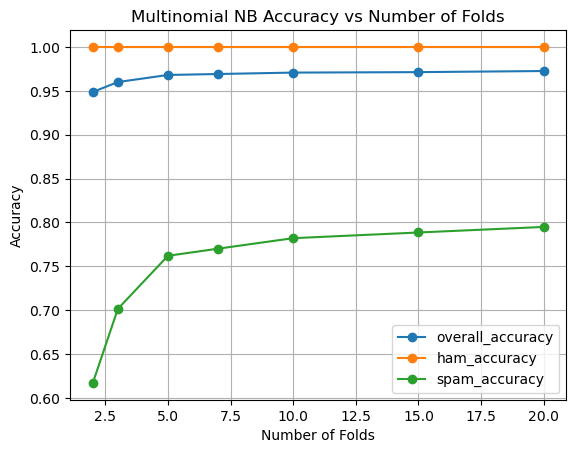

                 overall_accuracy  ham_accuracy  spam_accuracy
Number of Folds                                               
2                        0.948672           1.0       0.617140
3                        0.959979           1.0       0.701561
5                        0.968053           1.0       0.762013
7                        0.969131           1.0       0.770121
10                       0.970746           1.0       0.782081
15                       0.971279           1.0       0.788551
20                       0.972538           1.0       0.794882


In [105]:
list_folds = [2, 3, 5, 7, 10, 15, 20]
results = {'overall_accuracy': [], 'ham_accuracy': [], 'spam_accuracy': []}

for folds in list_folds:
    # Perform k-fold cross-validation using test_cross_validation
    fold_results = test_cross_validation_nbc(in_file='data/spam.csv', vectorizer_func=TfidfVectorizer, folds=folds)
    
    # Compute average accuracies across folds
    overall_accuracy = sum(fold_results['test_accuracy']) / folds
    ham_accuracy = sum(fold_results['ham_test_accuracy']) / folds
    spam_accuracy = sum(fold_results['spam_test_accuracy']) / folds
    
    results['overall_accuracy'].append(overall_accuracy)
    results['ham_accuracy'].append(ham_accuracy)
    results['spam_accuracy'].append(spam_accuracy)

# Plot the results
for key in results.keys():
    plt.plot(list_folds, results[key], marker='o', label=key)

plt.title('Multinomial NB Accuracy vs Number of Folds')
plt.xlabel('Number of Folds')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Save the results in a DataFrame
df_accuracies = pd.DataFrame(results, index=list_folds)
df_accuracies.index.name = 'Number of Folds'
print(df_accuracies)

df_accuracies.to_csv('multinomial_nb_accuracies_by_folds.csv', index=True)


In [129]:
for _ in range(10):
    fold_results = test_cross_validation_nbc(
        in_file='data/spam.csv', 
        vectorizer_func=TfidfVectorizer, 
        folds=10
    )
    # Compute average accuracies across folds
    overall_accuracy = sum(fold_results['test_accuracy']) / 10
    ham_accuracy = sum(fold_results['ham_test_accuracy']) / 10
    spam_accuracy = sum(fold_results['spam_test_accuracy']) / 10
    
    # Append results
    results['overall_accuracy'].append(overall_accuracy)
    results['ham_accuracy'].append(ham_accuracy)
    results['spam_accuracy'].append(spam_accuracy)

# Save the results in a DataFrame
df_accuracies = pd.DataFrame(results)
df_accuracies.index.name = 'Run'
print(df_accuracies)

# Save results to CSV
df_accuracies.to_csv('nbc_accuracies_k10_repeats.csv', index=True)

Fold 1/10
Overall Test Accuracy: 0.98
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.85
Fold 2/10
Overall Test Accuracy: 0.96
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.73
Fold 3/10
Overall Test Accuracy: 0.97
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.80
Fold 4/10
Overall Test Accuracy: 0.98
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.85
Fold 5/10
Overall Test Accuracy: 0.98
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.84
Fold 6/10
Overall Test Accuracy: 0.96
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.69
Fold 7/10
Overall Test Accuracy: 0.97
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.78
Fold 8/10
Overall Test Accuracy: 0.97
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.79
Fold 9/10
Overall Test Accuracy: 0.97
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.79
Fold 10/10
Overall Test Accuracy: 0.96
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.70
Fold 1/10
Overall Test Accuracy: 0.98
Ham Test Accuracy: 1.00
Spam Test Accuracy: 0.85
Fold 2/10
Overall Test Accuracy: 0.96
Ham 

In [104]:
print('Word Counts')
_ = test(in_file='data/mergedSpam.csv', vectorizer_func=CountVectorizer)
print('---------')
print('TFIDF')
_ = test(in_file='data/mergedSpam.csv', vectorizer_func=TfidfVectorizer)

Word Counts
Overall Accuracy
Training Accuracy: 0.99
Testing Accuracy: 0.98


KeyboardInterrupt: 

## KNN

In [13]:
print('Word Counts')
_ = test(in_file='data/mergedSpam.csv', vectorizer_func=CountVectorizer, classifier=KNeighborsClassifier, n_neighbors=3)
print('---------')
print('TFIDF')
_ = test(in_file='data/mergedSpam.csv', vectorizer_func=TfidfVectorizer, classifier=KNeighborsClassifier, n_neighbors=3)

Word Counts
Overall Accuracy
Training Accuracy: 0.92
Testing Accuracy: 0.89
ham Stats:
Proportion of Training Set: 0.86
Training Accuracy: 1.00
Proportion of Test Set: 0.87
Testing Accuracy: 1.00
spam Stats:
Proportion of Training Set: 0.14
Training Accuracy: 0.39
Proportion of Test Set: 0.13
Testing Accuracy: 0.17
---------
TFIDF
Overall Accuracy
Training Accuracy: 0.97
Testing Accuracy: 0.95
ham Stats:
Proportion of Training Set: 0.86
Training Accuracy: 1.00
Proportion of Test Set: 0.87
Testing Accuracy: 1.00
spam Stats:
Proportion of Training Set: 0.14
Training Accuracy: 0.79
Proportion of Test Set: 0.13
Testing Accuracy: 0.62


In [14]:
def knn_cross_validation(df=None, in_file=None, k=10, K_arr = (1, 3, 5, 7, 10, 15, 20), vectorizer_func=CountVectorizer, **kwargs):
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file)
    avg_accuracy = {cl: [0] * len(K_arr) for cl in ('Total', 'ham', 'spam')}
    std_error = {cl: [0] * len(K_arr) for cl in ('Total', 'ham', 'spam')}
    num_per_split = df.shape[0] // k
    for i, m in enumerate(K_arr):
        accuracy = {cl: [0] * k for cl in ('Total', 'ham', 'spam')}
        for idx in range(k):
            train_df = df.iloc[(num_per_split * idx):(num_per_split * (idx + 1))]
            train_set, vectorizer = vectorize(train_df, vectorizer_func=vectorizer_func)
            test_df = df.drop(train_set.index)
            test_set = vectorizer_transform_df(vectorizer, test_df)
            clf = train(df=train_set, classifier=KNeighborsClassifier, n_neighbors=m, **kwargs)
            accuracy['Total'][idx] = clf.score(test_set.drop(columns=['.class.']), test_set['.class.'])
            grouped = test_set.groupby('.class.')
            for cl, group in grouped:
                accuracy[cl][idx] = clf.score(group.drop(columns=['.class.']), group['.class.'])
        for cl in ('Total', 'ham', 'spam'):
            avg_accuracy[cl][i] = np.sum(accuracy[cl]) / k
            std_error[cl][i] = np.std(accuracy[cl]) / np.sqrt(k)
            #print(f'{m} Nearest Neighbors: {cl} - {avg_accuracy[cl][i]:.2f}')
    return avg_accuracy, std_error

In [15]:
def plot_knn_cross_validate():
    avg_accuracy = {}
    std_error = {}
    K_arr = (1, 3, 5, 7, 10, 15, 20)
    avg_accuracy['Word Count'], std_error['Word Count'] = knn_cross_validation(in_file='data/mergedSpam.csv', vectorizer_func=CountVectorizer, weights='distance')
    avg_accuracy['TF-IDF'], std_error['TF-IDF'] = knn_cross_validation(in_file='data/mergedSpam.csv', vectorizer_func=TfidfVectorizer, weights='distance')
    fig, ax = plt.subplots(2, 1)
    for i, vec in enumerate(('Word Count', 'TF-IDF')):
        for cl in ('Total', 'ham', 'spam'):
            ax[i].errorbar(K_arr, avg_accuracy[vec][cl], yerr=std_error[vec][cl], label=cl)
        ax[i].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax[i].set_xticks(range(21))
        ax[i].set_title(vec)
        ax[i].set_xlabel('k')
        ax[i].set_ylabel('Accuracy')
        ax[i].legend()
    fig.tight_layout()
    plt.show()
    return avg_accuracy, std_error

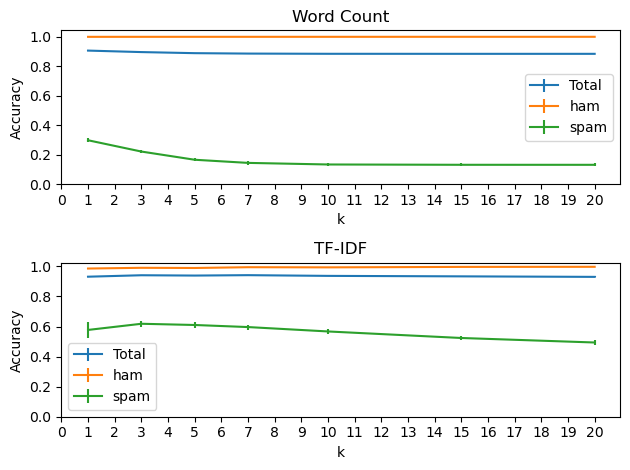

In [17]:
knn_cross_results = plot_knn_cross_validate()

## Cross Validation


In [112]:
def incremental_cross_validation(df=None, in_file=None, k=10, frac_arr = (0.025, 0.05, 0.075, 0.1, 0.15, 0.2), vectorizer_func=CountVectorizer, classifier=KNeighborsClassifier, **kwargs):
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file)
    avg_accuracy = {cl: [0] * len(frac_arr) for cl in ('Total', 'ham', 'spam')}
    std_error = {cl: [0] * len(frac_arr) for cl in ('Total', 'ham', 'spam')}
    num_per_split = df.shape[0] // k
    shuffled_df = df.sample(frac=1)
    for i, frac in enumerate(frac_arr):
        accuracy = {cl: [0] * k for cl in ('Total', 'ham', 'spam')}
        for idx in range(k):
            test_df = shuffled_df.iloc[(num_per_split * idx):(num_per_split * (idx + 1))]
            train_df = shuffled_df.drop(test_df.index)
            train_df = train_df.sample(frac=frac)
            train_set, vectorizer = vectorize(train_df, vectorizer_func=vectorizer_func)
            test_set = vectorizer_transform_df(vectorizer, test_df)
            clf = train(df=train_set, classifier=classifier, **kwargs)
            accuracy['Total'][idx] = clf.score(test_set.drop(columns=['.class.']), test_set['.class.'])
            grouped = test_set.groupby('.class.')
            for cl, group in grouped:
                accuracy[cl][idx] = clf.score(group.drop(columns=['.class.']), group['.class.'])
        for cl in ('Total', 'ham', 'spam'):
            avg_accuracy[cl][i] = np.sum(accuracy[cl]) / k
            std_error[cl][i] = np.std(accuracy[cl]) / np.sqrt(k)
    return avg_accuracy, std_error

In [113]:
def plot_incremental_cross_validate():
    avg_accuracy = {}
    std_error = {}
    frac_arr = np.array([0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5])
    k = 10
    fig, ax = plt.subplots(2, 2)
    df = pd.read_csv('data/mergedSpam.csv')
    for j, classifier in enumerate(('Multinomial Naive Bayes', '3-Nearest-Neighbors')):
        avg_accuracy[classifier] = {}
        std_error[classifier] = {}
        for i, vec in enumerate(('Word Count', 'TF-IDF')):
            vectorizer_func = CountVectorizer
            if vec == 'TF-IDF':
                vectorizer_func = TfidfVectorizer
            kwargs = {}
            classifier_func = MultinomialNB
            if classifier == '3-Nearest-Neighbors':
                classifier_func = KNeighborsClassifier
                kwargs['n_neighbors'] = 3
            avg_accuracy[classifier][vec], std_error[classifier][vec] = incremental_cross_validation(df=df, vectorizer_func=vectorizer_func, classifier=classifier_func, frac_arr=frac_arr, **kwargs) 
            for cl in ('Total', 'ham', 'spam'):
                ax[i][j].errorbar(frac_arr * df.shape[0] // k * 9, avg_accuracy[classifier][vec][cl], yerr=std_error[classifier][vec][cl], label=cl)
            ax[i][j].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
            #ax[i][j].set_xticks(np.arange(0, 0.425, 0.025))
            ax[i][j].set_title(f'{classifier} {vec}')
            ax[i][j].set_xlabel('Number of Samples')
            ax[i][j].set_ylabel('Accuracy')
            ax[i][j].legend()
    fig.tight_layout()
    plt.show()
    return avg_accuracy, std_error

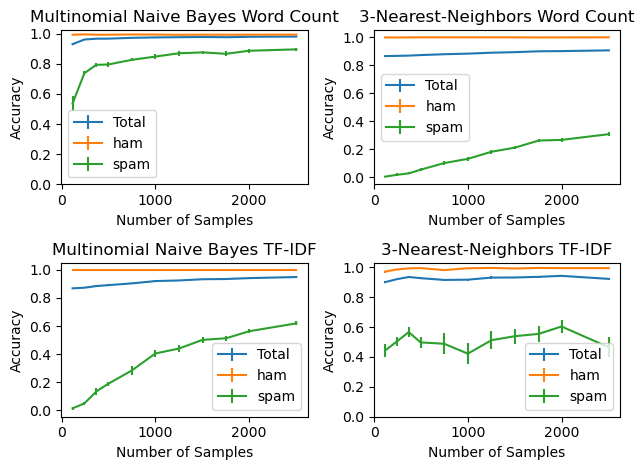

In [ ]:
incremental_results = plot_incremental_cross_validate()

In [23]:
def output_to_csv():
    knn_k_accuracy = knn_cross_results[0]
    pd.DataFrame.from_dict(knn_k_accuracy['Word Count']).to_csv('data/knn_k_wc_accuracy.csv')
    pd.DataFrame.from_dict(knn_k_accuracy['TF-IDF']).to_csv('data/knn_k_tfidf_accuracy.csv')
    incremental_nbc_accuracy = incremental_results[0]['Multinomial Naive Bayes']
    incremental_knn_accuracy = incremental_results[0]['Multinomial Naive Bayes']
    pd.DataFrame.from_dict(incremental_nbc_accuracy['Word Count']).to_csv('data/nbc_incremental_wc_accuracy.csv')
    pd.DataFrame.from_dict(incremental_nbc_accuracy['TF-IDF']).to_csv('data/nbc_incremental_tfidf_accuracy.csv')
    pd.DataFrame.from_dict(incremental_knn_accuracy['Word Count']).to_csv('data/knn_incremental_wc_accuracy.csv')
    pd.DataFrame.from_dict(incremental_knn_accuracy['TF-IDF']).to_csv('data/knn_incremental_tfidf_accuracy.csv')

In [119]:
def k_fold_cross_validation(df=None, in_file=None, k=10, vectorizer_func=TfidfVectorizer, classifier=KNeighborsClassifier, **kwargs):
    """
    Perform k-fold cross-validation for a classifier.
    :param df: The input dataframe.
    :param in_file: File path to read the dataframe (if df is None).
    :param k: Number of folds for k-fold cross-validation.
    :param vectorizer_func: Function to vectorize the text (default: CountVectorizer).
    :param classifier: Classifier to use (default: MultinomialNB).
    :param kwargs: Additional arguments for the classifier.
    :return: Dictionary containing average accuracy for each class.
    """
    if df is None:
        if in_file is None:
            raise ValueError("Either 'df' or 'in_file' must be provided.")
        df = pd.read_csv(in_file, encoding='ISO-8859-1')
    df = split(pd.read_csv('data/spam.csv', encoding = 'ISO-8859-1'))
    df['body'] = df['body'].apply(lambda x: ' '.join(x))
    
    vectorizer = vectorizer_func(**kwargs)
    X = vectorizer.fit_transform(df['body'])  # Assuming the text data is in a column named 'text'
    y = df['class']  # Assuming class labels are in a column named '.class.'
    
    # Shuffle data for k-fold
    shuffled_df = df.sample(frac=1, random_state=42)
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # Initialize result storage
    accuracy = {cl: [] for cl in ('Total', 'ham', 'spam')}

    for fold, (train_index, test_index) in enumerate(kf.split(shuffled_df), start=1):
        print(f"Fold {fold}/{k}")
        train_df, test_df = shuffled_df.iloc[train_index], shuffled_df.iloc[test_index]

        # Vectorize the data
        train_set, vectorizer = vectorize(train_df, vectorizer_func=vectorizer_func)
        test_set = vectorizer_transform_df(vectorizer, test_df)

        # Train the classifier
        clf = train(df=train_set, classifier=classifier, **kwargs)

        # Overall accuracy
        total_accuracy = clf.score(test_set.drop(columns=['.class.']), test_set['.class.'])
        accuracy['Total'].append(total_accuracy)
        print(f"Total Accuracy: {total_accuracy:.2f}")

        # Class-specific accuracy
        grouped = test_set.groupby('.class.')
        for cl, group in grouped:
            class_accuracy = clf.score(group.drop(columns=['.class.']), group['.class.'])
            accuracy[cl].append(class_accuracy)
            print(f"{cl.capitalize()} Accuracy: {class_accuracy:.2f}")

    # Calculate average and standard error
    avg_accuracy = {cl: np.mean(accuracy[cl]) for cl in accuracy}
    std_error = {cl: np.std(accuracy[cl]) / np.sqrt(k) for cl in accuracy}

    return avg_accuracy, std_error

In [122]:
list_folds = [2, 3, 5, 7, 10, 15, 20]
results = {'overall_accuracy': [], 'ham_accuracy': [], 'spam_accuracy': []}

for folds in list_folds:
    # Perform k-fold cross-validation using the `k_fold_cross_validation` function
    avg_accuracy, _ = k_fold_cross_validation(
        in_file='data/spam.csv', 
        vectorizer_func=TfidfVectorizer,  
        k=folds
    )
    
    # Append average accuracies to results
    results['overall_accuracy'].append(avg_accuracy['Total'])
    results['ham_accuracy'].append(avg_accuracy['ham'])
    results['spam_accuracy'].append(avg_accuracy['spam'])

# Plot the results
for key in results.keys():
    plt.plot(list_folds, results[key], marker='o', label=key)

plt.title('3NN vs Number of Folds')
plt.xlabel('Number of Folds')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Save the results in a DataFrame
df_accuracies = pd.DataFrame(results, index=list_folds)
df_accuracies.index.name = 'Number of Folds'
print(df_accuracies)

df_accuracies.to_csv('knn_accuracies_by_folds.csv', index=True)


KeyboardInterrupt: 

In [128]:
for _ in range(10):
    avg_accuracy, _ = k_fold_cross_validation(
        in_file='data/spam.csv', 
        vectorizer_func=TfidfVectorizer, 
        k=10
    )
    
    results['overall_accuracy'].append(avg_accuracy['Total'])
    results['ham_accuracy'].append(avg_accuracy['ham'])
    results['spam_accuracy'].append(avg_accuracy['spam'])

# Save the results in a DataFrame
df_accuracies = pd.DataFrame(results)
df_accuracies.index.name = 'Run'
print(df_accuracies)

# Save results to CSV
df_accuracies.to_csv('knn_accuracies_k10_repeats.csv', index=True)

Fold 1/10
Total Accuracy: 0.91
Ham Accuracy: 1.00
Spam Accuracy: 0.36
Fold 2/10
Total Accuracy: 0.89
Ham Accuracy: 1.00
Spam Accuracy: 0.36
Fold 3/10
Total Accuracy: 0.91
Ham Accuracy: 1.00
Spam Accuracy: 0.35
Fold 4/10
Total Accuracy: 0.91
Ham Accuracy: 1.00
Spam Accuracy: 0.34
Fold 5/10
Total Accuracy: 0.93
Ham Accuracy: 1.00
Spam Accuracy: 0.39
Fold 6/10
Total Accuracy: 0.91
Ham Accuracy: 0.99
Spam Accuracy: 0.39
Fold 7/10
Total Accuracy: 0.91
Ham Accuracy: 1.00
Spam Accuracy: 0.32
Fold 8/10
Total Accuracy: 0.92
Ham Accuracy: 1.00
Spam Accuracy: 0.37
Fold 9/10
Total Accuracy: 0.90
Ham Accuracy: 1.00
Spam Accuracy: 0.32
Fold 10/10
Total Accuracy: 0.91
Ham Accuracy: 1.00
Spam Accuracy: 0.37
Fold 1/10
Total Accuracy: 0.91
Ham Accuracy: 1.00
Spam Accuracy: 0.36
Fold 2/10
Total Accuracy: 0.89
Ham Accuracy: 1.00
Spam Accuracy: 0.36
Fold 3/10
Total Accuracy: 0.91
Ham Accuracy: 1.00
Spam Accuracy: 0.35
Fold 4/10
Total Accuracy: 0.91
Ham Accuracy: 1.00
Spam Accuracy: 0.34
Fold 5/10
Total Acc